In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [3]:
# Load the dataset
df = pd.read_csv('/content/gdrive/My Drive/Cardiovascular_Disease_Dataset.csv')

In [4]:
# Display first few rows
print(df.head())

   patientid  age  gender  chestpain  restingBP  serumcholestrol  \
0     103368   53       1          2        171                0   
1     119250   40       1          0         94              229   
2     119372   49       1          2        133              142   
3     132514   43       1          0        138              295   
4     146211   31       1          1        199                0   

   fastingbloodsugar  restingrelectro  maxheartrate  exerciseangia  oldpeak  \
0                  0                1           147              0      5.3   
1                  0                1           115              0      3.7   
2                  0                0           202              1      5.0   
3                  1                1           153              0      3.2   
4                  0                2           136              0      5.3   

   slope  noofmajorvessels  target  
0      3                 3       1  
1      1                 1       0  
2    

In [5]:
# Check dataset info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientid          1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   gender             1000 non-null   int64  
 3   chestpain          1000 non-null   int64  
 4   restingBP          1000 non-null   int64  
 5   serumcholestrol    1000 non-null   int64  
 6   fastingbloodsugar  1000 non-null   int64  
 7   restingrelectro    1000 non-null   int64  
 8   maxheartrate       1000 non-null   int64  
 9   exerciseangia      1000 non-null   int64  
 10  oldpeak            1000 non-null   float64
 11  slope              1000 non-null   int64  
 12  noofmajorvessels   1000 non-null   int64  
 13  target             1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB
None


In [6]:
# Check for missing values
print(df.isnull().sum())

patientid            0
age                  0
gender               0
chestpain            0
restingBP            0
serumcholestrol      0
fastingbloodsugar    0
restingrelectro      0
maxheartrate         0
exerciseangia        0
oldpeak              0
slope                0
noofmajorvessels     0
target               0
dtype: int64


In [7]:
# Fill missing values if any
df.fillna(df.median(), inplace=True)

In [8]:
# Encode categorical variables if any
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

In [9]:
# Assuming 'target' is the label
X = df.drop(columns=['target'])
y = df['target']

In [10]:
# Check class distribution
print(y.value_counts())

target
1    580
0    420
Name: count, dtype: int64


<ipython-input-11-e65c02ce3dc6>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['target'], palette='viridis')


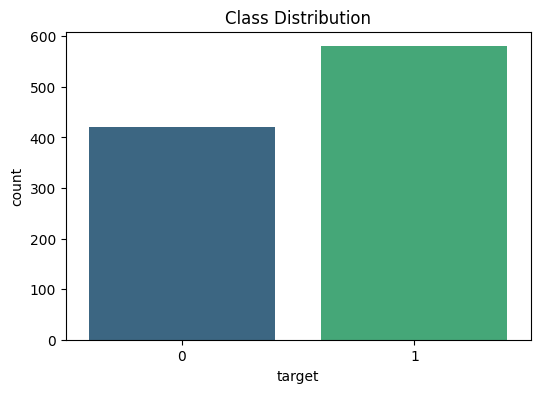

In [11]:
# Visualizing class balance
plt.figure(figsize=(6, 4))
sns.countplot(x=df['target'], palette='viridis')
plt.title('Class Distribution')
plt.show()

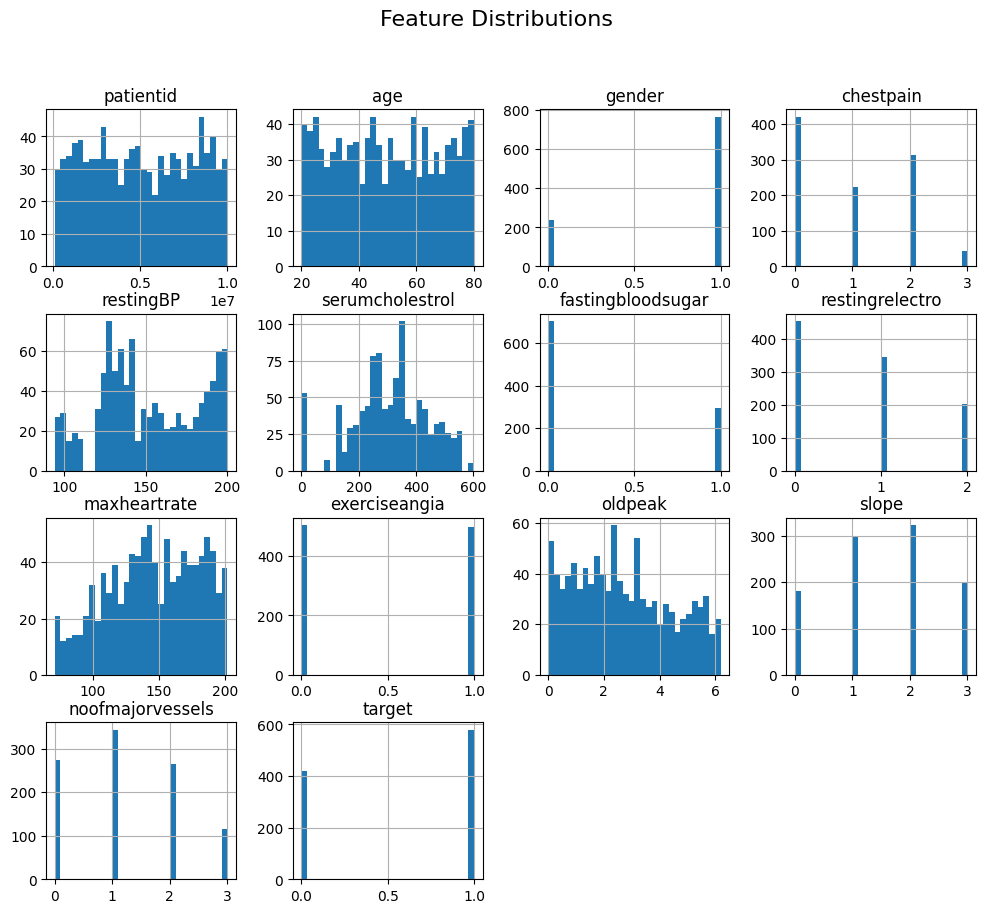

In [12]:
# Histograms for numerical features
df.hist(figsize=(12, 10), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

In [13]:
# Removing Outliers (Using IQR Method)
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

for col in df.select_dtypes(include=['number']).columns:
    df = remove_outliers(df, col)

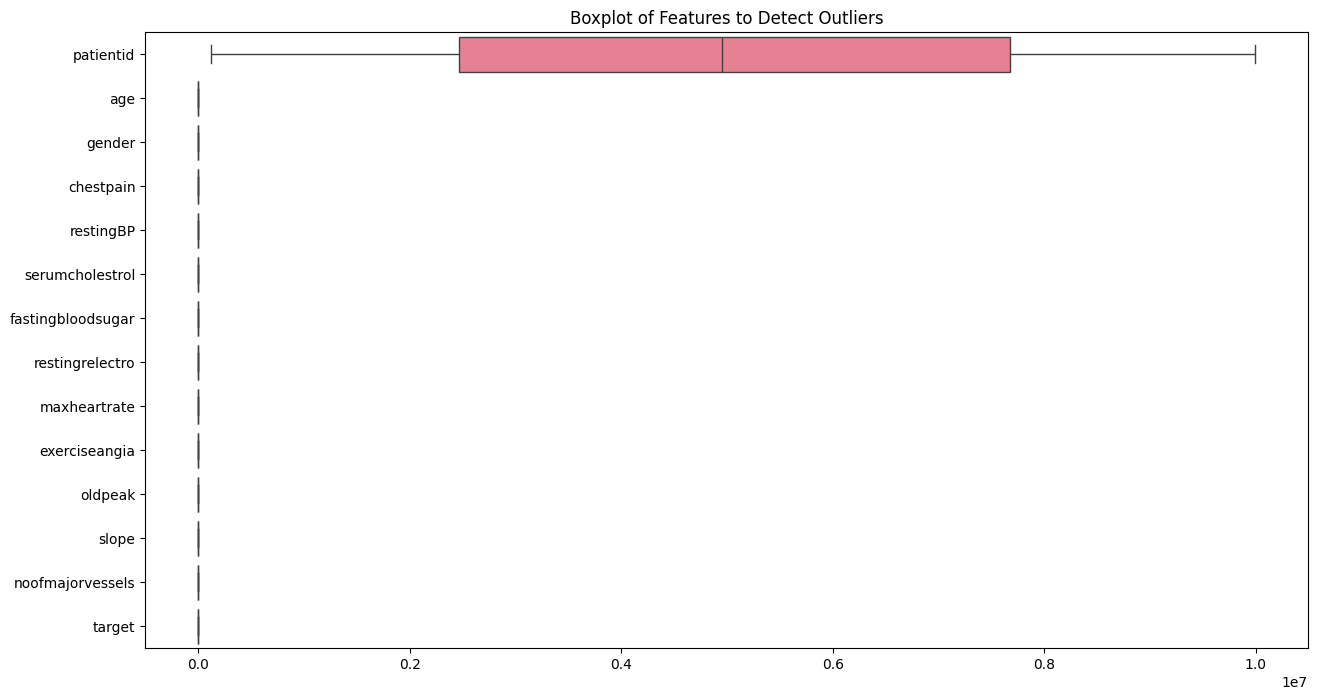

In [14]:
# Outlier Detection using Boxplot
plt.figure(figsize=(15, 8))
sns.boxplot(data=df, orient='h')
plt.title("Boxplot of Features to Detect Outliers")
plt.show()

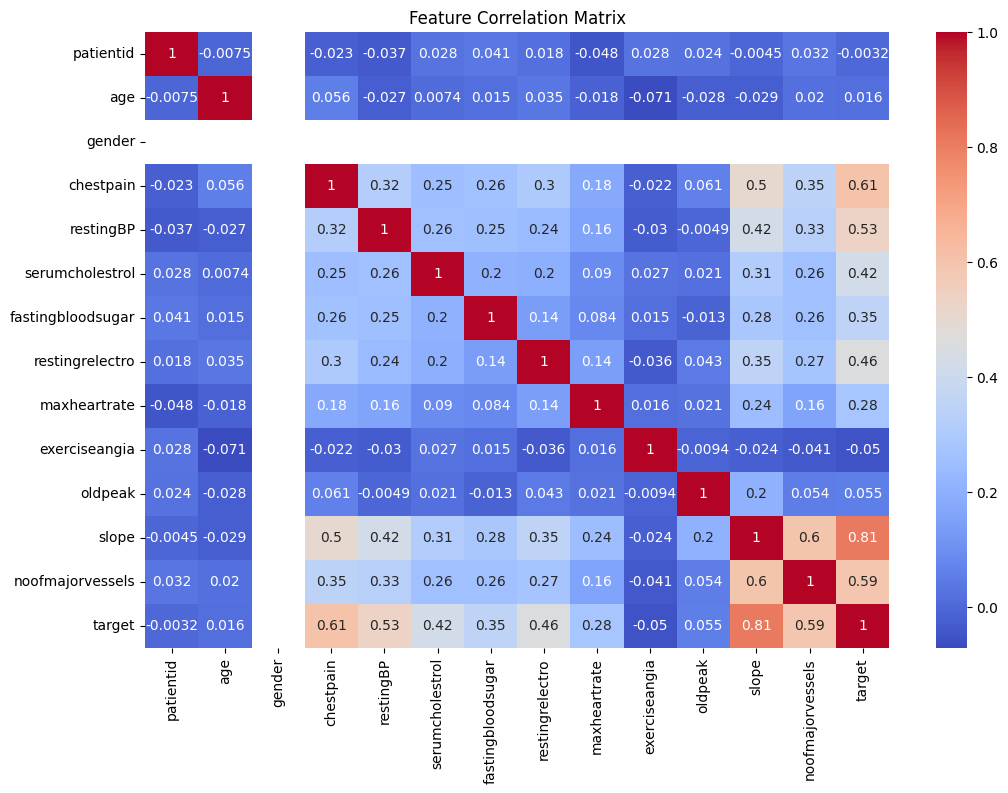

In [15]:
# Correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

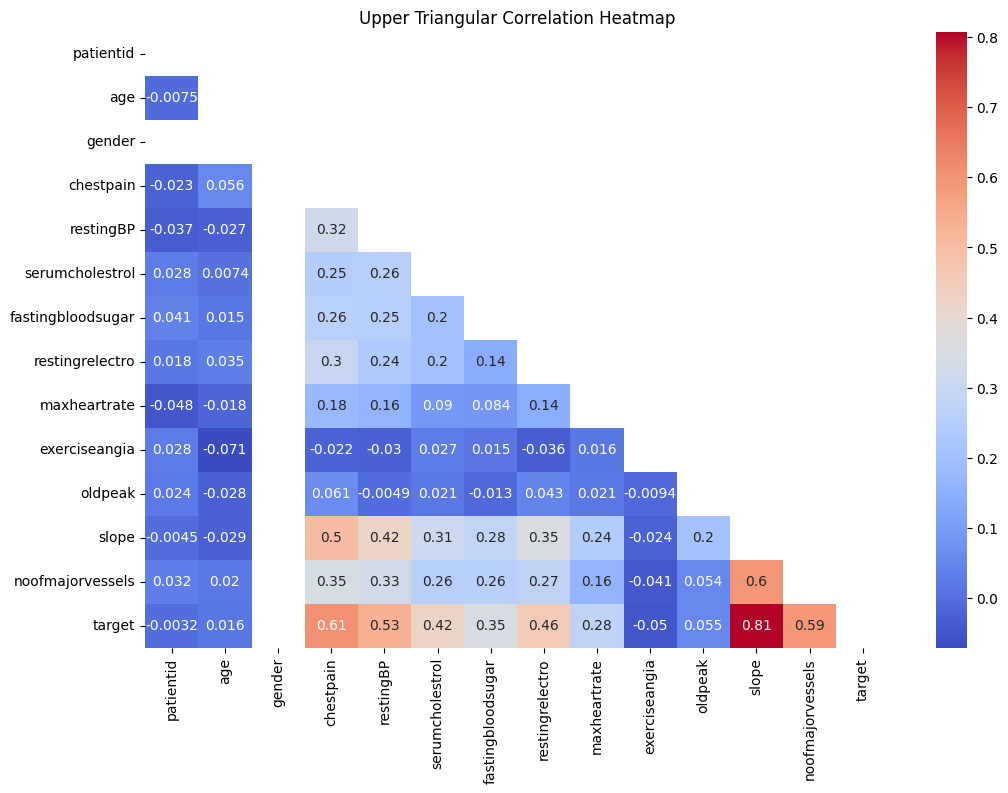

In [16]:
# Plotting the upper triangular heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm')
plt.title("Upper Triangular Correlation Heatmap")
plt.show()

In [17]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])  # All columns except target
y = df['target']  # Target column

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # random_state for reproducibility

# Print dataset shapes
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (575, 13) (575,)
Testing set shape: (144, 13) (144,)


In [18]:
# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
# Optimize the model - Hyperparameter tuning using GridSearchCV
param_grid = {'n_neighbors': np.arange(1, 21)}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])},
             scoring='f1')

In [20]:
# Get the best hyperparameters and the best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'n_neighbors': np.int64(17)}


In [21]:
# Create and train the optimized KNN model
knn = KNeighborsClassifier(n_neighbors=best_params['n_neighbors'])
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=np.int64(17))

In [22]:
# Predict on test set
y_pred = knn.predict(X_test)

In [23]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f'KNN Model Accuracy: {accuracy:.2f}')
print(classification_report(y_test, y_pred))

KNN Model Accuracy: 0.97
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        55
           1       0.98      0.98      0.98        89

    accuracy                           0.97       144
   macro avg       0.97      0.97      0.97       144
weighted avg       0.97      0.97      0.97       144



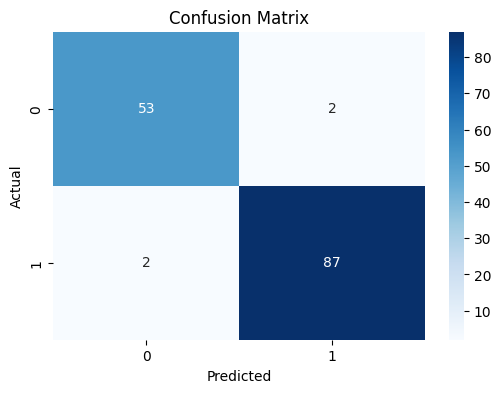

In [24]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
# Error rate analysis
error_rate = []
for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred_i = knn.predict(X_test)
    error_rate.append(np.mean(y_pred_i != y_test))

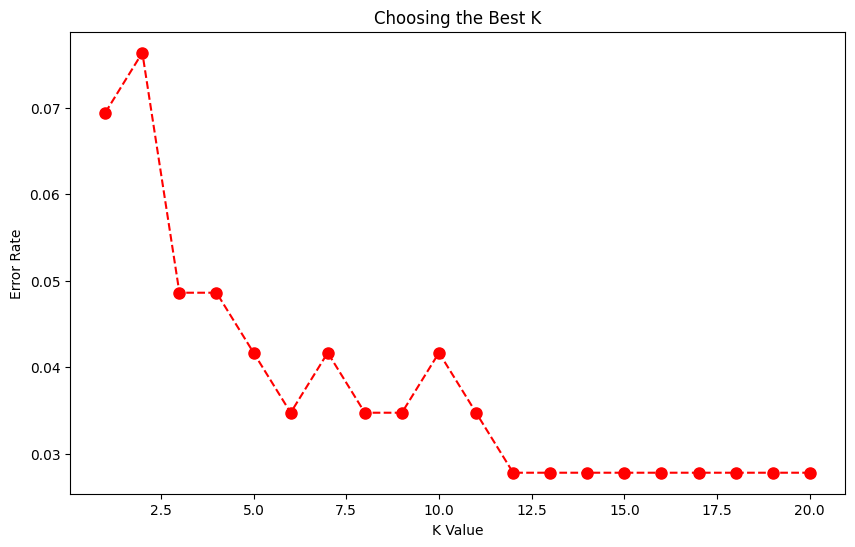

In [26]:
# Plot Error Rate vs K Value
plt.figure(figsize=(10,6))
plt.plot(range(1, 21), error_rate, marker='o', linestyle='dashed', markersize=8, color='r')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Choosing the Best K')
plt.show()

In [27]:
# Ensure the model is trained before making predictions
if not hasattr(knn, "classes_"):
    knn.fit(X_train, y_train)  # Fit the model if not already trained

# Predicting Disease for a New Patient
new_patient = np.array([[45, 1, 130, 85, 250, 1, 0, 0, 120, 1, 0, 0, 1]])

# Convert to DataFrame with correct feature names
new_patient_df = pd.DataFrame(new_patient, columns=X.columns)

# Scale the new patient data
new_patient_scaled = scaler.transform(new_patient_df)

# Predict the disease
predicted_disease = knn.predict(new_patient_scaled)
print(f'Predicted Disease: {predicted_disease[0]}')

Predicted Disease: 1


In [28]:
# Saving the model
joblib.dump(knn, 'knn_model.pkl')

['knn_model.pkl']